In [9]:
from vrae.vrae import VRAE
from vrae.utils import *
import numpy as np
import torch
import torch.nn as nn   
import pandas as pd
import plotly
from torch.utils.data import DataLoader, TensorDataset
plotly.offline.init_notebook_mode()
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.model_selection import train_test_split
import seaborn as sns
import os
import shutil
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import sklearn.metrics

df = pd.read_pickle(fr'C:\Users\achfr\OneDrive - University of Edinburgh\Compiled dataset\df_compiled_mothers_labelled_cyclefate.csv')
df_tracks= df.pivot(values=[
    'GrowthRateSize','GrowthRateLength','GrowthRateFeretMax','GrowthRateFeretMaxSliding',
    'InterdivisionTimes','DivisionRate','DivisionRate_filtered','TrackLength','TrackLength_filtered',
    'Size','SizeAtBirthSize','FeretMax','SizeAtBirthFeretMax','MaxLength','SpineLength','SizeAtBirthLength','SpineWidth',
    'MeanIntensity_mch','MeanIntensity_gfp','Maxgfp',
    'BacteriaLineage','NextDivisionFrame','PreviousDivisionFrame',
    'TrackHeadIndices','Prev','Next','Idx','Frame','Indices','PositionIdx','cellcycle_fate'], 
    index=['Position','ParentTrackHeadIndices','Medium','Treatment','RepeatID','RepeatDate','fate','DeathSubtype'],
    columns='Time')

In [ ]:
import importlib
import vrae.vrae

# Force reload the module
importlib.reload(vrae.vrae)

['gly' 'control' '3' '371']
train (57607, 72, 1)
train no aug (6102, 72, 1)
test (699, 72, 1)


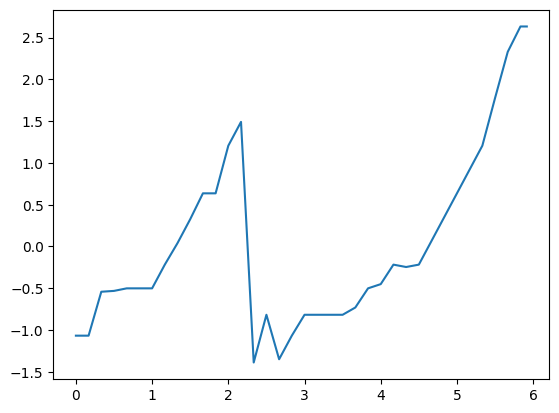

In [2]:
#### Creating dataset and splitting it into train and test sets then data augmentation
liste_x=[]
liste_y=[]

# dataset_name_list = ['gly_control_1', 'gly_control_2', 'gly_control_3', 'gly_cip_1', 'gly_cip_2', 'gly_tet_1', 'gly_tet_2', 'gly_tet_3', 'gly_ciptet_1', 'gly_ciptet_2', 'glu_control_1', 'glu_control_2', 'glu_cip_1', 'glu_cip_2', 
#  'glu_tet_1', 'glu_tet_2', 'glu_ciptet_1', 'glu_ciptet_2', 'gluaa_control_1', 'gluaa_control_2', 'gluaa_cip_1', 'gluaa_cip_2', 'gluaa_cip_3', 'gluaa_tet_1', 'gluaa_tet_2', 'gluaa_ciptet_1', 'gluaa_ciptet_2']
dataset_name_list = ['gly_control_1','gly_control_2','gly_control_3','glu_control_1','glu_control_2','gluaa_control_1','gluaa_control_2']

for exp_name in dataset_name_list:

    medium,treatment,replicate = exp_name.split('_')

    frame = df_tracks.loc(axis=0)[:,:,medium,treatment,replicate]
    size_array = np.array([list(frame['FeretMax'].T[k]) for k in frame['FeretMax'].T.keys()])
    cyclefate_array = np.array([list(frame['cellcycle_fate'].T[k]) for k in frame['cellcycle_fate'].T.keys()])

    for i in range(size_array.shape[0]):
        size_serie =  size_array[i]
        ##fill nans missing timepoints with the mean of the previous and next timepoints
        for j in range(1,len(size_serie)-1):
            if np.isnan(size_serie[j]):
                size_serie[j] = np.mean([size_serie[j-1],size_serie[j+1]])
        cyclefate_serie = cyclefate_array[i]
        ##fill nans missing timepoints with the next fate timepoint
        for j in range(len(cyclefate_serie)-1):
            if cyclefate_serie[j] == 'nan':
                cyclefate_serie[j] = cyclefate_serie[j+1]

        t_death = len(cyclefate_serie)
        if np.where(cyclefate_serie != 'alive')[0].shape[0] > 0:
            t_death = np.where(cyclefate_serie != 'alive')[0][0]

        usable_data = size_serie[:min(t_death,288)]

        if len(usable_data) > 72:
            liste_x.append(usable_data)
            liste_y.append((medium,treatment,replicate,t_death))

X_train_preaug, X_test_preaug, y_train_preaug, y_test_preaug = train_test_split(liste_x, liste_y, test_size=0.1, random_state=42, shuffle=True)

##### in X_train we change eahc sequence to series of size 72 with a roling window of 12
liste_x_train = []
liste_y_train = []
for i in range(len(X_train_preaug)):
    usable_data = X_train_preaug[i]
    for j in range(0, len(usable_data) - 72 + 1, 6):
        liste_x_train.append(usable_data[j:j+72])
        liste_y_train.append(y_train_preaug[i])
X_train = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_train))
y_train = np.array(liste_y_train)

## no augmentation
liste_x_train_noaug = []
liste_y_train_noaug = []
for i in range(len(X_train_preaug)):
    usable_data = X_train_preaug[i]
    for j in range(0, len(usable_data) - 72 + 1, 72):
        liste_x_train_noaug.append(usable_data[j:j + 72])
        liste_y_train_noaug.append(y_train_preaug[i])
X_train_noaug = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_train_noaug))
y_train_noaug = np.array(liste_y_train_noaug)

# In X_test we cut each sequence into unique 72-long sequences
liste_x_test = []
liste_y_test = []
for i in range(len(X_test_preaug)):
    usable_data = X_test_preaug[i]
    for j in range(0, len(usable_data) - 72 + 1, 72):
        liste_x_test.append(usable_data[j:j + 72])
        liste_y_test.append(y_test_preaug[i])
X_test = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_test))
y_test = np.array(liste_y_test)

r = np.random.randint(0,X_train.shape[0])
serie = X_train[r]
print(y_train[r])
plt.plot(np.arange(0,len(serie))/12,serie)

# num_elements_to_duplicate = 200 - X_test.shape[0] # Calculate the number of elements to duplicate
# indices_to_duplicate = np.random.choice(X_test.shape[0], num_elements_to_duplicate, replace=True)# Randomly select indices to duplicate
# X_test_augmented = np.concatenate((X_test, X_test[indices_to_duplicate]), axis=0)# Duplicate the selected elements
# test_dataset_augmented = TensorDataset(torch.from_numpy(X_test_augmented))
print('train', X_train.shape)
print('train no aug', X_train_noaug.shape)
print('test', X_test.shape)

In [ ]:
# pca tsne and clustering gly glu gluaa
liste_x_embed = []
liste_y_embed = []
for i in range(len(liste_x)):
    usable_data = liste_x[i]
    for j in range(0, len(usable_data) - 72 + 1, 72):
        liste_x_embed.append(usable_data[j:j+72])
        liste_y_embed.append(liste_y[i])
X_embed = TimeSeriesScalerMeanVariance().fit_transform(np.array(liste_x_embed))
y_embed = np.array(liste_y_embed)

embed_dataset = TensorDataset(torch.from_numpy(X_embed).to('cuda'))

vrae.batch_size = 1
projected_data = vrae.transform(embed_dataset)

from sklearn.decomposition import TruncatedSVD,PCA
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

z_run_pca = TruncatedSVD(n_components=10).fit_transform(projected_data)

z_run_tsne = TSNE(perplexity=80, min_grad_norm=1E-12, n_iter=300).fit_transform(projected_data)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))

colors = ['purple', 'yellow', 'orange']
for i,media in enumerate(['gluaa','gly','glu']):
    ax[0].scatter(z_run_pca[y_embed == media, 0], z_run_pca[y_embed == media, 1], color=colors[i], label=media,marker='x',alpha=0.8)
    ax[1].scatter(z_run_tsne[y_embed == media, 0], z_run_tsne[y_embed == media, 1], color=colors[i], label=media,marker='x',alpha=0.8)


# ax[0].set_title('PCA')
# ax[1].set_title('t-SNE')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].set_xlabel('t-SNE1')
ax[1].set_ylabel('t-SNE2')
# plt.legend()

projected_data.shape

#clustering all data 3 clusters
from sklearn.cluster import KMeans, DBSCAN
import sklearn.metrics

label_map_growth_contitions = {'gly':0, 'glu':1, 'gluaa':2}
label_conditions = np.array([label_map_growth_contitions[k[0]] for k in y_embed])

km_clustering = KMeans(n_clusters=3, n_init = 100).fit(projected_data)
km_labels = km_clustering.labels_

label_conditions_survived = np.array([label_map_growth_contitions[k[0]] for k in y_embed if k[3] != 'melon'])
km_labels_survived = km_clustering.labels_[[k[3] != 'melon' for k in y_embed]]

print(np.unique(km_labels_survived, return_counts=True))
print(np.unique(label_conditions_survived, return_counts=True))
print(sklearn.metrics.rand_score(label_conditions_survived, km_labels_survived))
print(sklearn.metrics.adjusted_rand_score(label_conditions_survived, km_labels_survived))
confusion_matrix = sklearn.metrics.confusion_matrix(label_conditions_survived, km_labels_survived)
confusion_matrix = confusion_matrix*100/np.sum(confusion_matrix)
plt.figure(figsize=(10, 10))
# sns.heatmap(confusion_matrix, annot=True, fmt='d', xticklabels=False, yticklabels=False, cbar=False)
sns.heatmap(confusion_matrix, annot=True, xticklabels=False, yticklabels=False, cbar=False, annot_kws={"size": 20})

fig, ax = plt.subplots(1, 2, figsize=(15, 7))

colors = ['yellow', 'orange', 'purple']
for i,media in enumerate([0,1,2]):
    ax[0].scatter(z_run_pca[km_labels == media, 0], z_run_pca[km_labels == media, 1], color=colors[i], label=media,marker='x',alpha=0.8)
    ax[1].scatter(z_run_tsne[km_labels == media, 0], z_run_tsne[km_labels == media, 1], color=colors[i], label=media,marker='x',alpha=0.8)
# ax[0].set_title('PCA')
# ax[1].set_title('t-SNE')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].set_xlabel('t-SNE1')
ax[1].set_ylabel('t-SNE2')


In [7]:
latent_length = 10 ## import a latent length model 

##################
train_dataset = TensorDataset(torch.from_numpy(X_train).to('cuda'))
test_dataset = TensorDataset(torch.from_numpy(X_test))

sequence_length = X_train.shape[1]
number_of_features = X_train.shape[2]

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 200
learning_rate = 0.001 # 0.0005
n_epochs = 200
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae = VRAE(sequence_length=sequence_length,
            number_of_features = number_of_features,
            hidden_size = hidden_size, 
            hidden_layer_depth = hidden_layer_depth,
            latent_length = latent_length,
            batch_size = batch_size,
            learning_rate = learning_rate,
            n_epochs = n_epochs,
            dropout_rate = dropout_rate,
            optimizer = optimizer, 
            cuda = cuda,
            print_every=print_every, 
            clip=clip, 
            max_grad_norm=max_grad_norm,
            loss = loss,
            block = block,
            dload = dload)

vrae.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_results_test\model_{latent_length}.pth')


c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.



In [ ]:
vrae.eval()
testseq2 = test_dataset[:batch_size][0].float().permute(1, 0, 2).cuda()
outp = vrae.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=97
input_seq = testseq2[:,k,0].cpu().detach().numpy()
output_seq = outp[0][:,k,0].cpu().detach().numpy()
plt.figure()
plt.plot(input_seq.T)
plt.plot(output_seq.T)

loss = vrae.loss_fn
print(loss(testseq2[:,k,0], outp[0][:,k,0]))


In [ ]:
#get reconstruction loss for every cell in test set

latent_length = 10 ## import a latent length model 

##################
train_dataset = TensorDataset(torch.from_numpy(X_train).to('cuda'))
test_dataset = TensorDataset(torch.from_numpy(X_test))

sequence_length = X_train.shape[1]
number_of_features = X_train.shape[2]

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 1
learning_rate = 0.001 # 0.0005
n_epochs = 200
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae = VRAE(sequence_length=sequence_length,
            number_of_features = number_of_features,
            hidden_size = hidden_size, 
            hidden_layer_depth = hidden_layer_depth,
            latent_length = latent_length,
            batch_size = batch_size,
            learning_rate = learning_rate,
            n_epochs = n_epochs,
            dropout_rate = dropout_rate,
            optimizer = optimizer, 
            cuda = cuda,
            print_every=print_every, 
            clip=clip, 
            max_grad_norm=max_grad_norm,
            loss = loss,
            block = block,
            dload = dload)

vrae.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_results_test\model_{latent_length}.pth')

vrae.eval()
vrae.batch_size = 1
test_loader = DataLoader(test_dataset, batch_size=vrae.batch_size, shuffle=True)
reconstruction_loss = []
seqs = []
for i, data in enumerate(test_loader, 0):
    testseq = data[0].float().permute(1, 0, 2).cuda()
    outp = vrae.forward(testseq)
    for j in range(vrae.batch_size):
        lossr = vrae.loss_fn(testseq[:,j,0], outp[0][:,j,0]).item()
        reconstruction_loss.append(lossr)
        seqs.append((testseq[:,j,0].cpu().detach().numpy(), outp[0][:,j,0].cpu().detach().numpy()))

# plt.hist(reconstruction_loss, bins=100)
sns.kdeplot(np.array(reconstruction_loss)[[k[0]=='gly' for k in y_test]], color = 'yellow', fill=False, label = 'gly')
sns.kdeplot(np.array(reconstruction_loss)[[k[0]=='glu' for k in y_test]], color = 'orange', fill=False, label = 'glu')
sns.kdeplot(np.array(reconstruction_loss)[[k[0]=='gluaa' for k in y_test]], color = 'purple', fill=False, label = 'gluaa')
plt.xlabel('Reconstruction loss')
plt.ylabel('Frequency')
plt.title('Reconstruction loss distribution')
plt.legend()

In [ ]:
k = np.argmin(reconstruction_loss)
input_seq,output_seq = seqs[k]

plt.figure()
plt.plot(input_seq.T)
plt.plot(output_seq.T)
print(reconstruction_loss[k])

In [ ]:
print(chr(sum(range(ord(min(str(not())))))))

In [ ]:
# # train cell with test
# replicate = 9

# import time
# from vrae.vrae import VRAE
# from vrae.utils import *
# t0 = time.time()

# train_dataset = TensorDataset(torch.from_numpy(X_train).to('cuda'))
# # train_dataset = TensorDataset(torch.from_numpy(X_train_noaug).to('cuda'))
# test_dataset = TensorDataset(torch.from_numpy(X_test))

# sequence_length = X_train.shape[1]
# number_of_features = X_train.shape[2]

# dload = './model_dir_mm' #download directory
# hidden_size = 90
# hidden_layer_depth = 2
# batch_size = 200
# learning_rate = 0.001 # 0.0005
# n_epochs = 200
# dropout_rate = 0.2
# optimizer = 'Adam' # options: ADAM, SGD
# cuda = True # options: True, False
# print_every=1000
# clip = True # options: True, False
# max_grad_norm=5
# loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
# block = 'LSTM' # options: LSTM, GRU


# for latent_length in range(20,2-1,-1):
#     print('latent_length\t',latent_length,'\t elapsed time\t',(time.time()-t0)/60,' minutes\t',(time.time()-t0)/3600.0,' hours')

#     vrae = VRAE(sequence_length=sequence_length,
#                 number_of_features = number_of_features,
#                 hidden_size = hidden_size, 
#                 hidden_layer_depth = hidden_layer_depth,
#                 latent_length = latent_length,
#                 batch_size = batch_size,
#                 learning_rate = learning_rate,
#                 n_epochs = n_epochs,
#                 dropout_rate = dropout_rate,
#                 optimizer = optimizer, 
#                 cuda = cuda,
#                 print_every=print_every, 
#                 clip=clip, 
#                 max_grad_norm=max_grad_norm,
#                 loss = loss,
#                 block = block,
#                 dload = dload)

#     vrae.fit(train_dataset, test_dataset, save=True)

#     file = open(fr'C:\Users\achfr\timeseries-clustering-vae\model_dir_mm\print.txt').readlines()
#     train_losses = []
#     test_losses = []
#     for line in file:
#         if 'Average loss' in line:
#             train_losses.append(float(line.split(' ')[-2]))
#             test_losses.append(float(line.split(' ')[-1][:-2]))
#             # print(float(line.split(' ')[-2]),float(line.split(' ')[-1][:-2]))

#     shutil.move(fr'C:\Users\achfr\timeseries-clustering-vae\model_dir_mm\model.pth', fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\model_{replicate}_{latent_length}.pth')
#     shutil.move(fr'C:\Users\achfr\timeseries-clustering-vae\model_dir_mm\model_best.pth', fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\model_best_{replicate}_{latent_length}.pth')
#     np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\train_losses_{replicate}_{latent_length}.npy', train_losses)
#     np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\test_losses_{replicate}_{latent_length}.npy', test_losses)

In [ ]:
### print losses graph 
%matplotlib inline
## all train lossses
train_losses_list = []
latent_lengths = range(20, 2-1, -1)
colors = cm.jet(np.linspace(0, 1, len(latent_lengths))) 
plt.figure(figsize=(10, 6))
for i, latent_length in enumerate(latent_lengths):
    lossesx = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_results_test\train_losses_{latent_length}.npy')
    train_losses_list.append(lossesx)
    plt.plot(train_losses_list[-1], label=latent_length, color=colors[i], alpha=0.7)
plt.legend(title='Latent Length', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Losses for Different Latent Lengths')
plt.tight_layout()
plt.show()

# ## all test losses
# test_losses_list = []
# latent_lengths = range(20, 2-1, -1)
# colors = cm.jet(np.linspace(0, 1, len(latent_lengths))) 
# plt.figure(figsize=(10, 6))
# for i, latent_length in enumerate(latent_lengths):
#     lossesx = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_results_test\test_losses_{latent_length}.npy')
#     test_losses_list.append(lossesx)
#     plt.plot(test_losses_list[-1], label=latent_length, color=colors[i], alpha=0.7)
# plt.legend(title='Latent Length', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Test Losses for Different Latent Lengths')
# plt.tight_layout()

# ## final train losses
# final_train_losses = [train_losses_list[i][-1] for i in range(len(train_losses_list))]
# final_test_losses = [test_losses_list[i][-1] for i in range(len(test_losses_list))]
# plt.figure(figsize=(10, 6))
# plt.plot(latent_lengths, final_train_losses, label='Train', marker='o')
# plt.plot(latent_lengths, final_test_losses, label='Test', marker='o')
# plt.xlabel('Latent Length')
# plt.ylabel('Loss')
# plt.title('Final Losses for Different Latent Lengths')
# plt.legend()
# plt.tight_layout()

# ## min train and test losses
# min_train_losses = [min(train_losses_list[i]) for i in range(len(train_losses_list))]
# min_test_losses = [min(test_losses_list[i]) for i in range(len(test_losses_list))]
# plt.figure(figsize=(10, 6))
# plt.plot(latent_lengths, min_train_losses, label='Train', marker='o')
# plt.plot(latent_lengths, min_test_losses, label='Test', marker='o')
# plt.xlabel('Latent Length')
# plt.ylabel('Loss')
# plt.title('Minimum Losses for Different Latent Lengths')
# plt.legend()
# plt.tight_layout()


##some train lossses
train_losses_list2 = []
latent_lengths = range(20, 2-1, -1)
colors = cm.jet(np.linspace(0, 1, len(latent_lengths))) 
plt.figure(figsize=(10, 6))
for i, latent_length in enumerate(latent_lengths):
    if latent_length in [20, 18, 14, 9, 5, 2]:
        lossesx = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_results_test\train_losses_{latent_length}.npy')
        train_losses_list2.append(lossesx)
        plt.plot(train_losses_list2[-1], label=latent_length, color=colors[i], alpha=0.7)
plt.legend(title='Latent Length', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Losses for Different Latent Lengths')
plt.tight_layout()

## final and min train losses
final_train_losses = [train_losses_list[i][-1] for i in range(len(train_losses_list))]
min_train_losses = [min(train_losses_list[i]) for i in range(len(train_losses_list))]
plt.figure(figsize=(10, 6))
plt.plot(latent_lengths, final_train_losses, label='Final', marker='x')
plt.plot(latent_lengths, min_train_losses, label='Min', marker='x')
plt.xlabel('Latent Length')
plt.ylabel('Loss')
plt.xticks(latent_lengths)
plt.title('Final and Minimum loss for Different Latent Lengths')
plt.legend()
plt.tight_layout()


In [6]:
#### Embed everything karoui

dataset_name_list = ['gly_control_1', 'gly_control_2', 'gly_control_3', 'gly_cip_1', 'gly_cip_2', 'gly_tet_1', 'gly_tet_2', 'gly_tet_3', 'gly_ciptet_1', 'gly_ciptet_2', 'glu_control_1', 'glu_control_2', 'glu_cip_1', 'glu_cip_2', 
 'glu_tet_1', 'glu_tet_2', 'glu_ciptet_1', 'glu_ciptet_2', 'gluaa_control_1', 'gluaa_control_2', 'gluaa_cip_1', 'gluaa_cip_2', 'gluaa_cip_3', 'gluaa_tet_1', 'gluaa_tet_2', 'gluaa_ciptet_1', 'gluaa_ciptet_2']
dataset_lengths = [188,376,304,252,307,317,277,411,328,431, 78,342,386,377,351,354,355,350,283,334,218,191,235,327,237,343,304]

liste_x=[]
liste_y=[]

for exp_name in dataset_name_list:
    print(exp_name)
    medium,treatment,replicate = exp_name.split('_')

    frame = df_tracks.loc(axis=0)[:,:,medium,treatment,replicate]
    size_array = np.array([list(frame['FeretMax'].T[k]) for k in frame['FeretMax'].T.keys()])
    cyclefate_array = np.array([list(frame['cellcycle_fate'].T[k]) for k in frame['cellcycle_fate'].T.keys()])

    for i in range(size_array.shape[0]):
        size_serie =  size_array[i]
        ##fill nans missing timepoints with the mean of the previous and next timepoints
        for j in range(1,len(size_serie)-1):
            if np.isnan(size_serie[j]):
                size_serie[j] = np.mean([size_serie[j-1],size_serie[j+1]])
        cyclefate_serie = cyclefate_array[i]
        ##fill nans missing timepoints with the next fate timepoint
        for j in range(len(cyclefate_serie)-1):
            if cyclefate_serie[j] == 'nan':
                cyclefate_serie[j] = cyclefate_serie[j+1]

        t_death = len(cyclefate_serie)
        if np.where(cyclefate_serie != 'alive')[0].shape[0] > 0:
            t_death = np.where(cyclefate_serie != 'alive')[0][0]

        usable_data = size_serie[:min(t_death,168)]

        if len(usable_data) > 72:
            liste_x.append(usable_data)
            liste_y.append((medium,treatment,replicate,t_death))

# Create the dataset
Scaled = TimeSeriesScalerMeanVariance().fit_transform(np.array([x[:72] for x in liste_x]))
all_dataset = TensorDataset(torch.from_numpy(Scaled).to('cuda'))

label_map = {
    ('gly', 'control'): 0,
    ('gly', 'cip'): 1,
    ('gly', 'tet'): 2,
    ('gly', 'ciptet'): 3,
    ('glu', 'control'): 4,
    ('glu', 'cip'): 5,
    ('glu', 'tet'): 6,
    ('glu', 'ciptet'): 7,
    ('gluaa', 'control'): 8,
    ('gluaa', 'cip'): 9,
    ('gluaa', 'tet'): 10,
    ('gluaa', 'ciptet'): 11
}

labels = [label_map[k[:2]] for k in liste_y]
map_growth = {'gly':0, 'glu':1, 'gluaa':2}
labels_growth = [map_growth[k[0]] for k in liste_y]

gly_control_1
gly_control_2
gly_control_3
gly_cip_1
gly_cip_2
gly_tet_1
gly_tet_2
gly_tet_3
gly_ciptet_1
gly_ciptet_2
glu_control_1
glu_control_2
glu_cip_1
glu_cip_2
glu_tet_1
glu_tet_2
glu_ciptet_1
glu_ciptet_2
gluaa_control_1
gluaa_control_2
gluaa_cip_1
gluaa_cip_2
gluaa_cip_3
gluaa_tet_1
gluaa_tet_2
gluaa_ciptet_1
gluaa_ciptet_2


In [5]:
#import tanouchi data
tanouchi_data = {25:[],27:[],37:[]}
for temp in [25,27,37]:
    folder_path = fr'C:\Users\achfr\OneDrive - University of Edinburgh\Tanouchi_data\Analysis_MC4100_{temp}C\MC4100_{temp}C'
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, delimiter=',', header=None)
        tanouchi_data[temp].append(df)

tanouchi_sequences = []
tanouchi_sequences_400 = []
tanouchi_y = []
for temp in [25,27,37]:
    for df in tanouchi_data[temp]:
        cell_size = df[2]
        cell_size = cell_size[::5]
        sequences = [np.array(cell_size[i:i+72]) for i in range(0, len(cell_size)-72, 72)]
        tanouchi_sequences_400.append(np.array(cell_size[:400]))
        tanouchi_sequences.extend(sequences)
        tanouchi_y.extend([temp]*len(sequences))

X_tanouchi = TimeSeriesScalerMeanVariance().fit_transform(np.array(tanouchi_sequences))
y_tanouchi = np.array(tanouchi_y)
tanouchi_dataset = TensorDataset(torch.from_numpy(X_tanouchi).to('cuda'))

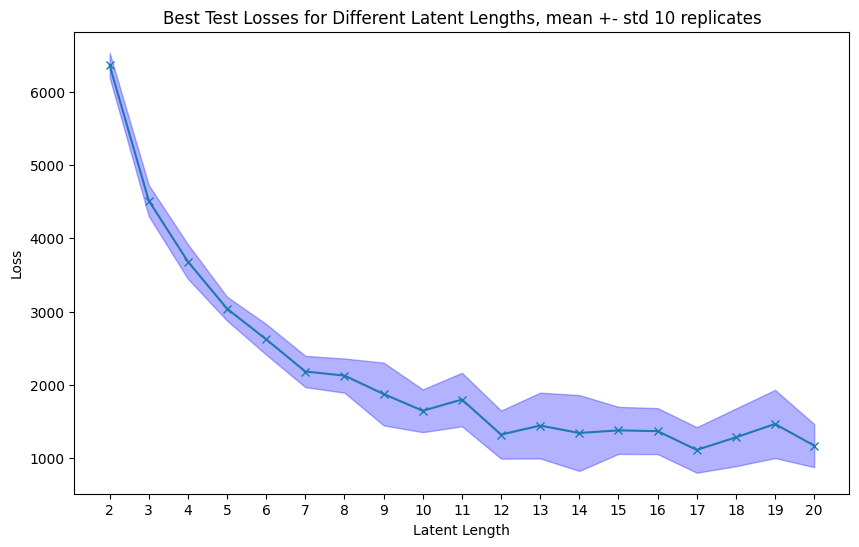

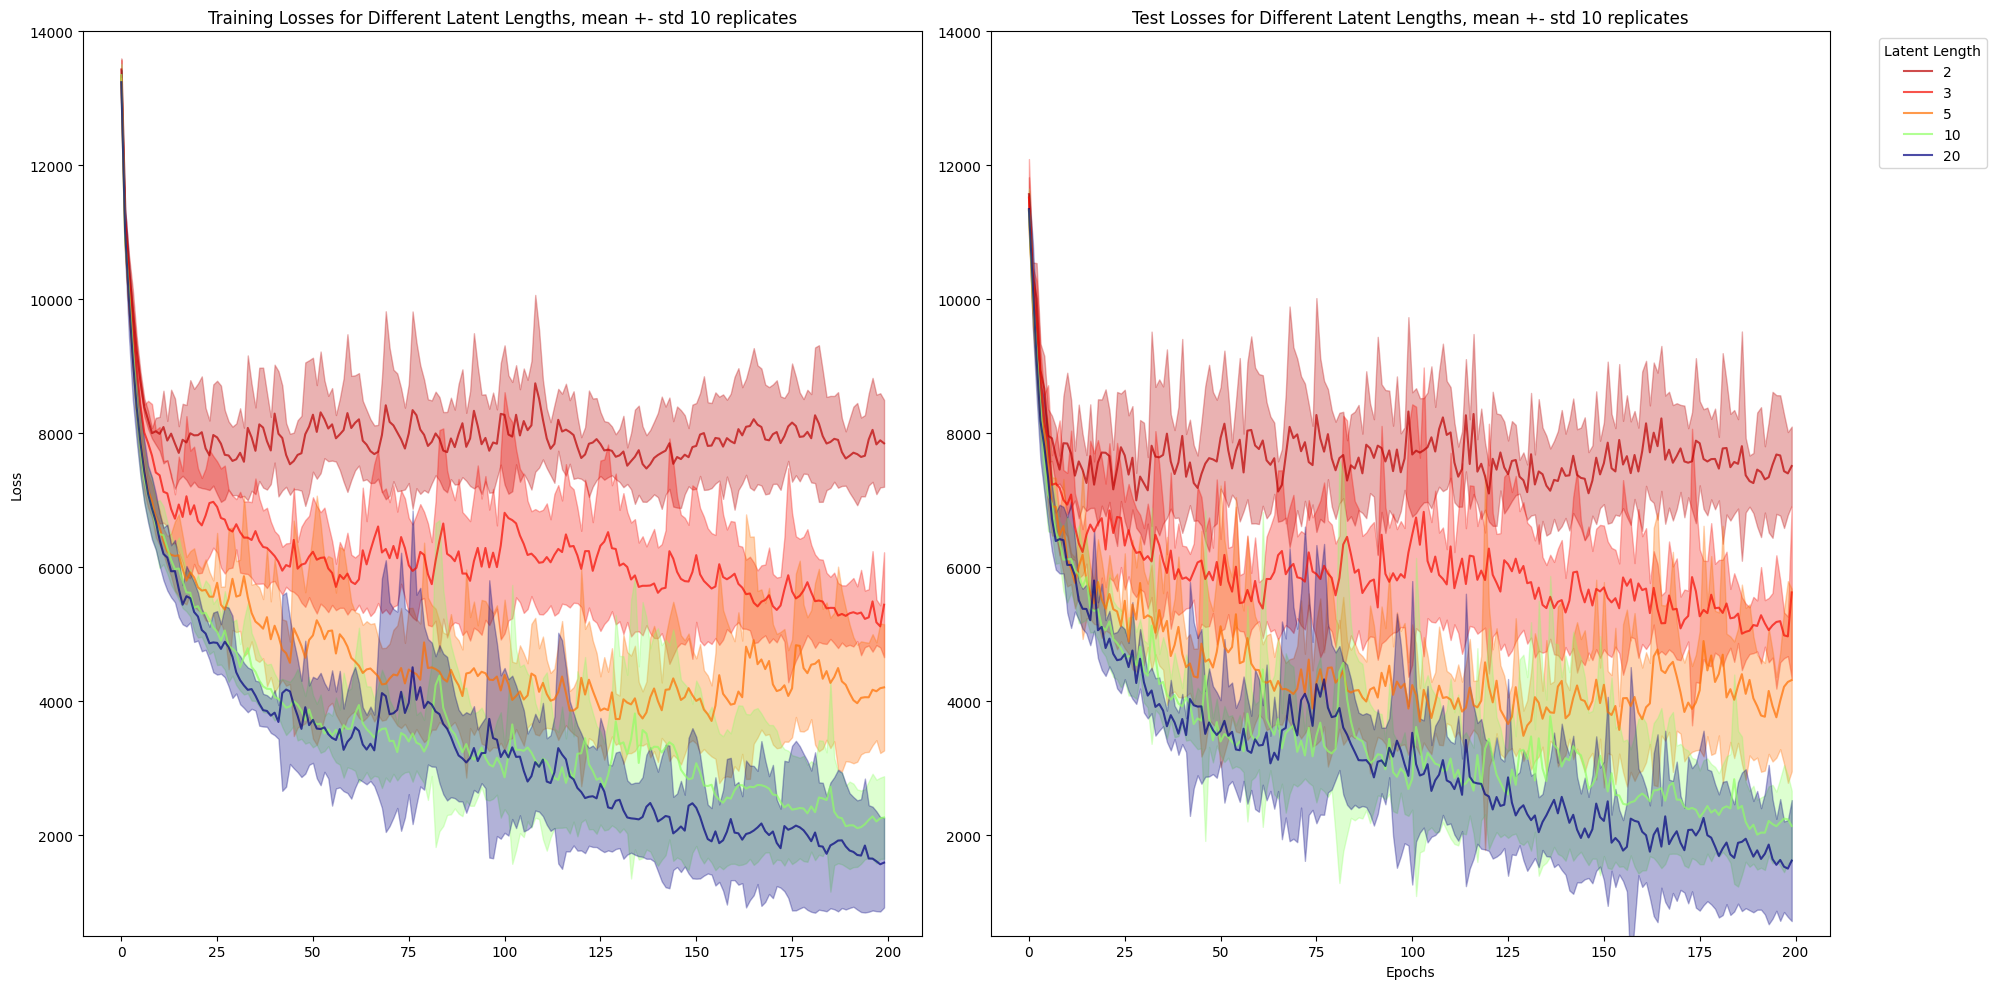

In [ ]:
#train/test losses graph
train_losses = {}
test_losses = {}
for latent_length in range(20,2-1,-1):
    train_losses[latent_length]=[]
    test_losses[latent_length]=[]
    for replicate in range(10):
        train_losses[latent_length].append(np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\train_losses_{replicate}_{latent_length}.npy'))
        test_losses[latent_length].append(np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\test_losses_{replicate}_{latent_length}.npy'))

#sugly plot
# latent_lengths = range(20, 2-1, -1)
# latent_lengths = [20,5,2]
# plt.figure(figsize=(10, 6))
# for latent_length in latent_lengths:
#     plt.plot(np.array(train_losses[latent_length]).T, color=colors[20-latent_length], alpha=0.7)
# # plt.legend(title='Latent Length', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Training Losses for Different Latent Lengths,  10 replicates')
# plt.tight_layout()

plt.figure(figsize=(10, 6))
mean_best_test = [np.mean([np.min(i) for i in test_losses[latent_length]]) for latent_length in range(20,2-1,-1)]
std_best_test = [np.std([np.min(i) for i in test_losses[latent_length]]) for latent_length in range(20,2-1,-1)]
plt.plot(range(20,2-1,-1), mean_best_test, label='Test', marker = 'x')
plt.fill_between(range(20,2-1,-1), np.array(mean_best_test) - np.array(std_best_test), np.array(mean_best_test) + np.array(std_best_test), alpha=0.3, edgecolor='blue', facecolor='blue')
plt.xlabel('Latent Length')
plt.ylabel('Loss')
plt.title('Best Test Losses for Different Latent Lengths, mean +- std 10 replicates')
plt.xticks(range(20,2-1,-1))

fig,ax = plt.subplots(1,2,figsize=(20, 10))

for latent_length in [2,3,5,10,20]:
    train_array = np.array(train_losses[latent_length])
    ax[0].plot(np.mean(train_array,axis=0), color=colors[20-latent_length], alpha=0.7, label = latent_length)
    ax[0].fill_between(range(200), np.mean(train_array,axis=0) - np.std(train_array,axis=0), np.mean(train_array,axis=0) + np.std(train_array,axis=0), alpha=0.3, edgecolor=colors[20-latent_length], facecolor=colors[20-latent_length])
    test_array = np.array(test_losses[latent_length])
    ax[1].plot(np.mean(test_array,axis=0), color=colors[20-latent_length], alpha=0.7, label = latent_length)
    ax[1].fill_between(range(200), np.mean(test_array,axis=0) - np.std(test_array,axis=0), np.mean(test_array,axis=0) + np.std(test_array,axis=0), alpha=0.3, edgecolor=colors[20-latent_length], facecolor=colors[20-latent_length])
plt.legend(title='Latent Length', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Training Losses for Different Latent Lengths, mean +- std 10 replicates')
ax[0].set_ylim(500,14000)
ax[1].set_ylim(500,14000)
ax[1].set_title('Test Losses for Different Latent Lengths, mean +- std 10 replicates')
plt.tight_layout()

# plt.plot(np.array(range(10,270,10))*(1/12), mean_bayes, color = "orange", label = 'no hyperparameter tuning')
# plt.fill_between(np.array(range(10,270,10))*(1/12), mean_bayes - std_bayes, mean_bayes + std_bayes, alpha=0.3, edgecolor='orange', facecolor='orange')
# np.array([np.mean(i[0]) for i in res_random]), np.array([np.std(i[0]) for i in res_random])

In [ ]:
# silhouette score for different latent lengths 10 replicates 20min
# sillouhette_scores = {}

# for latent_length in range(20,2-1,-1):
#     sillouhette_scores[latent_length] = []
#     print(latent_length)
#     for replicate in range(10):
#         vrae = VRAE(sequence_length=sequence_length,
#                 number_of_features = number_of_features,
#                 hidden_size = hidden_size, 
#                 hidden_layer_depth = hidden_layer_depth,
#                 latent_length = latent_length,
#                 batch_size = batch_size,
#                 learning_rate = learning_rate,
#                 n_epochs = n_epochs,
#                 dropout_rate = dropout_rate,
#                 optimizer = optimizer, 
#                 cuda = cuda,
#                 print_every=print_every, 
#                 clip=clip, 
#                 max_grad_norm=max_grad_norm,
#                 loss = loss,
#                 block = block,
#                 dload = dload)
#         vrae.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\model_best_{replicate}_{latent_length}.pth')
#         vrae.batch_size = 1
#         vrae.eval()
#         tanouchi_transformed = vrae.transform(tanouchi_dataset)
#         karoui_transformed = vrae.transform(all_dataset)
#         sillouhette_scores[latent_length].append((sklearn.metrics.silhouette_score(tanouchi_transformed, y_tanouchi),sklearn.metrics.silhouette_score(karoui_transformed, labels_growth)))
# np.save(fr'sillouhette_scores.npy', sillouhette_scores)

sillouhette_scores = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\sillouhette_scores.npy', allow_pickle=True).item()



# ARI for different latent lengths 10 replicates 20min
# from sklearn.cluster import KMeans
# randindex_tanouchi = {}
# randindex_karoui = {}

# for latent_length in range(20,2-1,-1):
#     randindex_tanouchi[latent_length] = []
#     randindex_karoui[latent_length] = []
#     print(latent_length)
#     for replicate in range(10):
#         vrae = VRAE(sequence_length=sequence_length,
#                 number_of_features = number_of_features,
#                 hidden_size = hidden_size, 
#                 hidden_layer_depth = hidden_layer_depth,
#                 latent_length = latent_length,
#                 batch_size = batch_size,
#                 learning_rate = learning_rate,
#                 n_epochs = n_epochs,
#                 dropout_rate = dropout_rate,
#                 optimizer = optimizer, 
#                 cuda = cuda,
#                 print_every=print_every, 
#                 clip=clip, 
#                 max_grad_norm=max_grad_norm,
#                 loss = loss,
#                 block = block,
#                 dload = dload)
#         vrae.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\model_best_{replicate}_{latent_length}.pth')
#         vrae.batch_size = 1
#         vrae.eval()
#         tanouchi_transformed = vrae.transform(tanouchi_dataset)
#         karoui_transformed = vrae.transform(all_dataset)

#         km_tanouchi = KMeans(n_clusters=3, n_init = 100).fit(tanouchi_transformed)
#         km_labels_tanouchi = km_tanouchi.labels_
#         km_karoui = KMeans(n_clusters=3, n_init = 100).fit(karoui_transformed)
#         km_labels_karoui = km_karoui.labels_

#         randindex_tanouchi[latent_length].append((sklearn.metrics.adjusted_rand_score(y_tanouchi, km_labels_tanouchi),sklearn.metrics.rand_score(y_tanouchi, km_labels_tanouchi),km_labels_tanouchi))
#         randindex_karoui[latent_length].append((sklearn.metrics.adjusted_rand_score(labels_growth, km_labels_karoui),sklearn.metrics.rand_score(labels_growth, km_labels_karoui),km_labels_karoui))
        
# np.save(fr'randindex_tanouchi.npy', randindex_tanouchi)
# np.save(fr'randindex_karoui.npy', randindex_karoui)
randindex_karoui = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\randindex_karoui.npy', allow_pickle=True).item()
randindex_tanouchi = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_savebest\randindex_tanouchi.npy', allow_pickle=True).item()


20


c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args w

19


c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args w

18


...

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args w

3


c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args w

2


c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.

c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args w

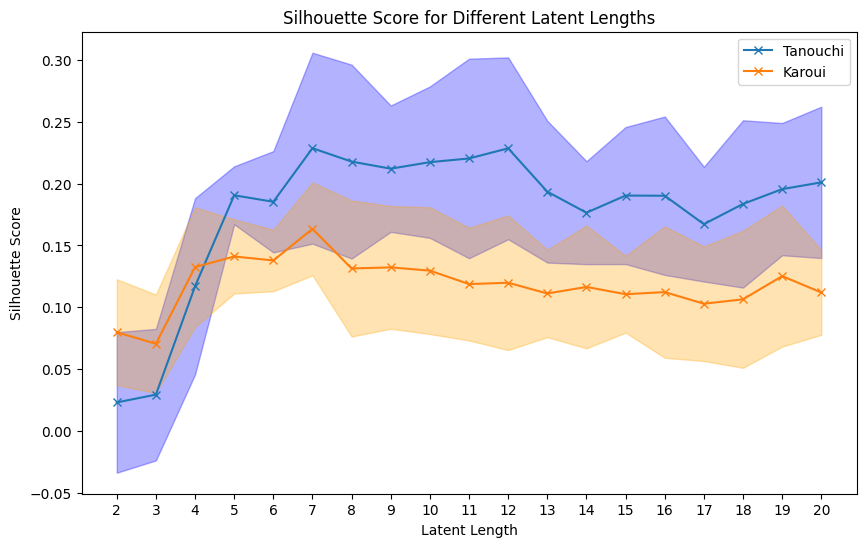

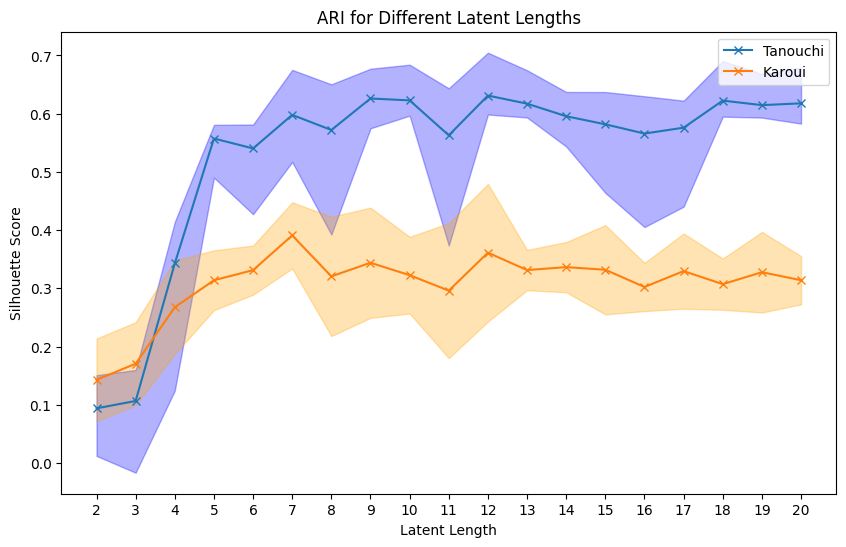

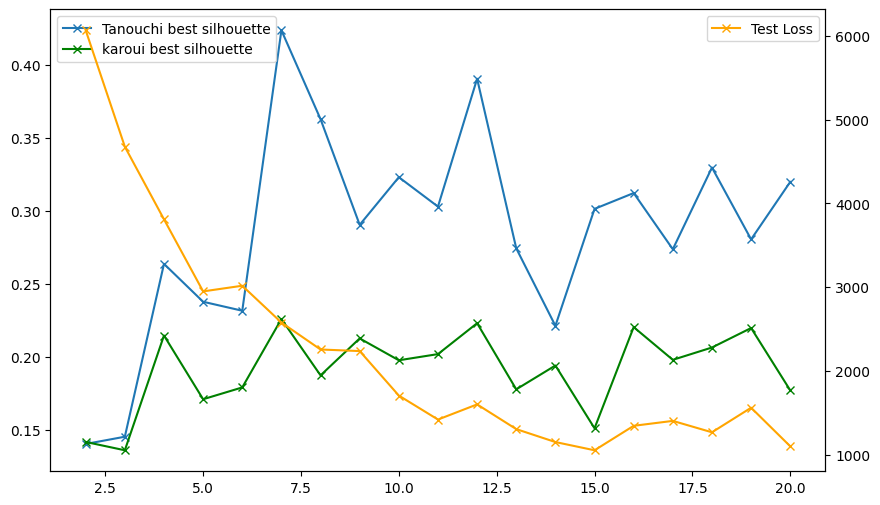

In [114]:
plt.figure(figsize=(10, 6))

meanz_tanouchi = np.array([np.mean([i[0] for i in sillouhette_scores[latent_length]]) for latent_length in range(20,2-1,-1)])
stdz_tanouchi =  np.array([np.std([i[0] for i in sillouhette_scores[latent_length]]) for latent_length in range(20,2-1,-1)])
meanz_karoui = np.array([np.mean([i[1] for i in sillouhette_scores[latent_length]]) for latent_length in range(20,2-1,-1)])
stdz_karoui =  np.array([np.std([i[1] for i in sillouhette_scores[latent_length]]) for latent_length in range(20,2-1,-1)])

plt.plot(range(20,2-1,-1), meanz_tanouchi, label='Tanouchi', marker = 'x')
plt.fill_between(range(20,2-1,-1), meanz_tanouchi - stdz_tanouchi, meanz_tanouchi + stdz_tanouchi, alpha=0.3, edgecolor='blue', facecolor='blue')
plt.plot(range(20,2-1,-1), meanz_karoui, label='Karoui', marker = 'x')
plt.fill_between(range(20,2-1,-1), meanz_karoui - stdz_karoui, meanz_karoui + stdz_karoui, alpha=0.3, edgecolor='orange', facecolor='orange')
plt.xlabel('Latent Length')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Latent Lengths')
plt.xticks(range(20,2-1,-1))
plt.legend()


plt.figure(figsize=(10, 6))

meanz_tanouchi_ARI = np.array([np.mean([i[0] for i in randindex_tanouchi[latent_length]]) for latent_length in range(20,2-1,-1)])
stdz_tanouchi_ARI =  np.array([np.std([i[0] for i in randindex_tanouchi[latent_length]]) for latent_length in range(20,2-1,-1)])
meanz_karoui_ARI = np.array([np.mean([i[0] for i in randindex_karoui[latent_length]]) for latent_length in range(20,2-1,-1)])
stdz_karoui_ARI =  np.array([np.std([i[0] for i in randindex_karoui[latent_length]]) for latent_length in range(20,2-1,-1)])


plt.plot(range(20,2-1,-1), meanz_tanouchi_ARI, label='Tanouchi', marker = 'x')
plt.fill_between(range(20,2-1,-1), meanz_tanouchi_ARI - stdz_tanouchi_ARI, meanz_tanouchi_ARI + stdz_tanouchi, alpha=0.3, edgecolor='blue', facecolor='blue')
plt.plot(range(20,2-1,-1), meanz_karoui_ARI, label='Karoui', marker = 'x')
plt.fill_between(range(20,2-1,-1), meanz_karoui_ARI - stdz_karoui_ARI, meanz_karoui_ARI + stdz_karoui_ARI, alpha=0.3, edgecolor='orange', facecolor='orange')
plt.xlabel('Latent Length')
plt.ylabel('Silhouette Score')
plt.title('ARI for Different Latent Lengths')
plt.xticks(range(20,2-1,-1))
plt.legend()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(range(20,2-1,-1), [np.max(np.array([i[0] for i in sillouhette_scores[latent_length]])) for latent_length in range(20,2-1,-1)], label='Tanouchi best silhouette', marker = 'x')
ax1.plot(range(20,2-1,-1), [np.max(np.array([i[1] for i in sillouhette_scores[latent_length]])) for latent_length in range(20,2-1,-1)], label='karoui best silhouette', marker = 'x', color = 'green')
ax2 = ax1.twinx()
ax2.plot(range(20,2-1,-1), [np.min(test_losses[latent_length][np.argmax(np.array([i[0] for i in sillouhette_scores[latent_length]]))]) for latent_length in range(20,2-1,-1)], label='Test Loss', marker = 'x', color = 'orange')
#plot test losses on another axis

ax1.legend(loc='upper left')
ax2.legend()

In [ ]:
for latent_length in range(20,2-1,-1):
    all_scores = np.array([i[0] for i in sillouhette_scores[latent_length]])

    print(np.max(all_scores),latent_length,np.argmax(all_scores), np.min(test_losses[latent_length][np.argmax(all_scores)]))

0.31991872 20 8 1099.528
0.2804973 19 5 1560.072
0.32976228 18 7 1266.667
0.2737194 17 5 1402.799
0.31225744 16 9 1344.173
0.30140796 15 3 1051.972
0.22121634 14 0 1150.207
0.2743325 13 1 1304.607
0.39066926 12 3 1599.875
0.30295172 11 8 1418.828
0.32313693 10 0 1705.243
0.2904631 9 8 2236.509
0.3629137 8 8 2255.296
0.42389512 7 1 2577.302
0.23153958 6 2 3016.491
0.23769811 5 0 2948.965
0.26369005 4 8 3809.61
0.14513256 3 7 4676.254
0.14016241 2 2 6066.542


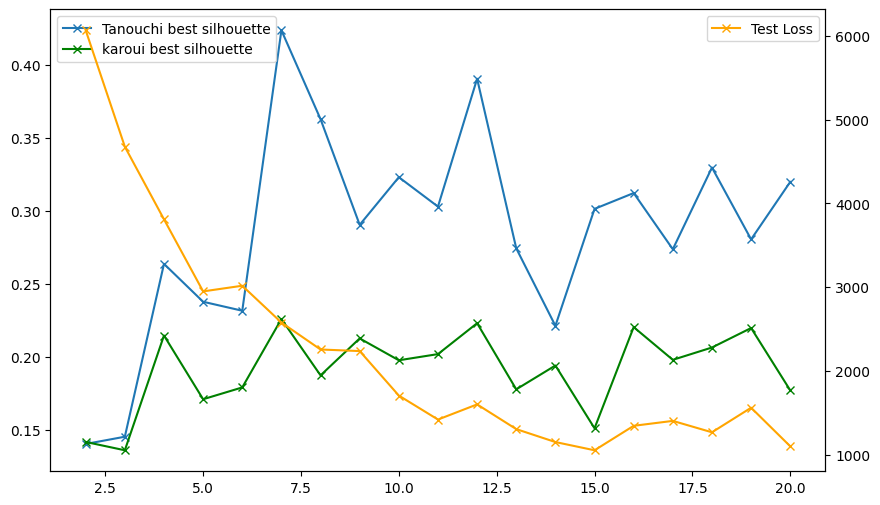

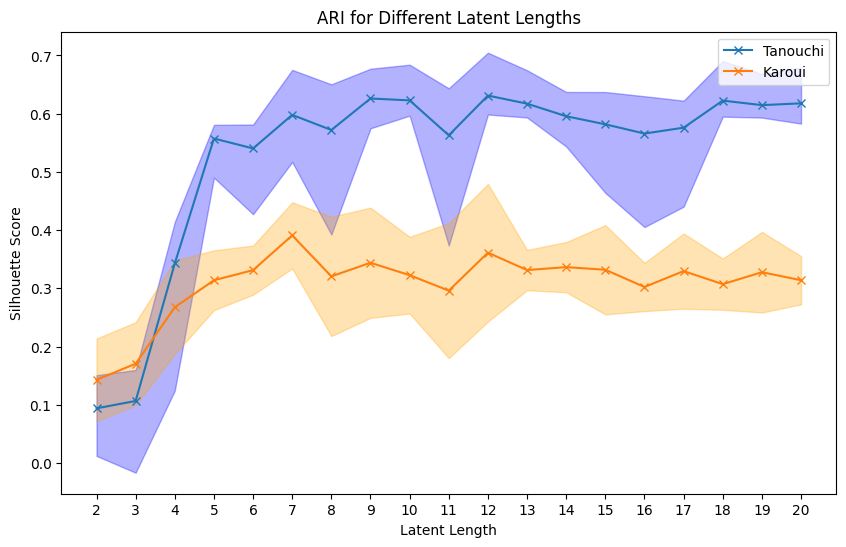